<a href="https://colab.research.google.com/github/worldstar0722/IS_Research_2025/blob/main/IS_RESEARCH_group_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S&P 500 Daily Up/Down Prediction Using Machine Learning by Julia

This notebook builds a machine learning model that predicts whether a stock’s closing price will go up or down the next trading day.
We use historical price data from S&P 500 companies, generate technical indicators as features, and train a LightGBM classifier to estimate next-day direction probabilities.


The workflow includes:
- Collecting S&P 500 ticker symbols
- Downloading historical price data from Yahoo Finance
- Feature engineering (returns, moving averages, RSI, volatility)
- Time-based train/test split
- Model training and evaluation
- Generating next-day directional predictions

This project demonstrates how to build a scalable, automated stock direction prediction pipeline.

In [ ]:
# Step 1. Install & imports
!pip install yfinance --quiet
!pip install lightgbm --quiet
!pip install ta --quiet
!pip install tqdm --quiet

import numpy as np
import pandas as pd
import yfinance as yf
import datetime
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import lightgbm as lgb
import ta
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Step 2. PARAMETERS - edit these to control quick run vs full run
SAMPLE_ONLY = False        # True = run only with a small sample (fast). Set False to use all tickers.
START_DATE = "2018-01-01"
# Use today's date as end
END_DATE = datetime.date.today().isoformat()
CUTOFF_DATE = "2023-01-01"  # for time-based test split

print("Quick run sample mode:", SAMPLE_ONLY)
print("Sample size:", SAMPLE_SIZE)
print("Date range:", START_DATE, "to", END_DATE)

Quick run sample mode: False


NameError: name 'SAMPLE_SIZE' is not defined

In [ ]:
# Step 3. Load S&P 500 tickers from a stable CSV source
url = "https://datahub.io/core/s-and-p-500-companies/r/constituents.csv"
sp500 = pd.read_csv(url)
tickers_all = sp500['Symbol'].str.replace('.', '-', regex=False).tolist()

if SAMPLE_ONLY:
    # deterministic sample for reproducibility (first N)
    tickers = tickers_all[:SAMPLE_SIZE]
else:
    tickers = tickers_all.copy()

print("Total available tickers:", len(tickers_all))
print("Tickers to process (count):", len(tickers))
print("Tickers preview:", tickers[:min(20, len(tickers))])

In [ ]:
# Step 4 code: robust sequential download with fallback
import time
from tqdm import tqdm
import yfinance as yf
import pandas as pd

# Ensure tickers, START_DATE, END_DATE are defined (from previous cells)
try:
    tickers
except NameError:
    tickers = ["AAPL","MSFT","TSLA","AMZN","NVDA"]

START_DATE = globals().get("START_DATE", "2018-01-01")
END_DATE   = globals().get("END_DATE", pd.Timestamp.today().strftime("%Y-%m-%d"))

def download_one_with_fallback(ticker, start, end, retries=3, pause=1.0):
    last_exc = None
    for attempt in range(retries):
        try:
            df = yf.download(ticker, start=start, end=end, progress=False)
            if df is None or df.shape[0] == 0:
                # fallback to history
                tk = yf.Ticker(ticker)
                hist = tk.history(start=start, end=end, period=None)
                if hist is None or hist.shape[0] == 0:
                    raise ValueError("no rows returned")
                df = hist
            # select required cols
            cols = [c for c in ['Open','High','Low','Close','Adj Close','Volume'] if c in df.columns]
            if 'Close' not in df.columns:
                raise ValueError("missing Close")
            df = df[cols].dropna()
            return df
        except Exception as e:
            last_exc = e
            time.sleep(pause * (attempt + 1))
    return {"error": str(last_exc)}

data_dict = {}
failed = []
for t in tqdm(tickers, desc="Sequential download"):
    res = download_one_with_fallback(t, START_DATE, END_DATE, retries=3, pause=1.0)
    if isinstance(res, dict) and res.get("error"):
        failed.append((t, res["error"]))
        time.sleep(0.3)
        continue
    df = res
    if df.shape[0] <= 60:
        failed.append((t, f"too few rows: {df.shape[0]}"))
        time.sleep(0.1)
        continue
    data_dict[t] = df
    time.sleep(0.2)  # polite pause

print("Downloaded tickers:", len(data_dict))
print("Failed tickers (sample):", failed[:10])

Sequential download:  70%|██████▉   | 352/503 [02:49<01:08,  2.21it/s]

In [ ]:
# Step 5: Robust featurize and build all_feats
import numpy as np
import pandas as pd
import time
from tqdm import tqdm

# Ensure data_dict exists: if not, download a small fallback set (AAPL, MSFT, TSLA, AMZN, NVDA)
try:
    data_dict
except NameError:
    data_dict = {}

if not isinstance(data_dict, dict) or len(data_dict) == 0:
    print("data_dict empty or missing — downloading fallback tickers for demo.")
    import yfinance as yf
    fallback = ["AAPL","MSFT","TSLA","AMZN","NVDA"]
    for t in fallback:
        try:
            df = yf.download(t, start="2018-01-01", end=pd.Timestamp.today().strftime("%Y-%m-%d"), progress=False)
            if df is not None and df.shape[0] > 60:
                # keep required columns and dropna
                cols = [c for c in ['Open','High','Low','Close','Adj Close','Volume'] if c in df.columns]
                data_dict[t] = df[cols].dropna()
        except Exception as e:
            print("Fallback download failed for", t, ":", e)

if len(data_dict) == 0:
    raise RuntimeError("No data available in data_dict and fallback downloads failed. Please ensure download step succeeded.")

# Robust featurize function
try:
    import ta
    TA_AVAILABLE = True
except Exception:
    TA_AVAILABLE = False

def featurize_safe(df):
    """
    Input: df (pandas DataFrame) with Close (and optionally Volume)
    Output: df with features and target_up
    This function avoids passing 2D arrays to ta functions and handles dtype conversions.
    """
    df = df.copy()

    # Ensure index is DatetimeIndex if possible
    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index)
        except Exception:
            pass

    # Ensure Close is 1D Series of float
    df['Close'] = pd.to_numeric(df['Close'].squeeze(), errors='coerce').astype(float)
    if 'Volume' in df.columns:
        df['Volume'] = pd.to_numeric(df['Volume'].squeeze(), errors='coerce').astype(float)

    # Basic features
    df['return_1'] = df['Close'].pct_change(1)
    df['return_2'] = df['Close'].pct_change(2)
    df['return_5'] = df['Close'].pct_change(5)
    df['ma_5'] = df['Close'].rolling(5).mean()
    df['ma_10'] = df['Close'].rolling(10).mean()
    df['ma_20'] = df['Close'].rolling(20).mean()
    df['ma_ratio_5_20'] = df['ma_5'] / (df['ma_20'] + 1e-9)
    df['vol_20'] = df['return_1'].rolling(20).std()

    # RSI (use ta if available, otherwise fallback)
    try:
        if TA_AVAILABLE:
            df['rsi_14'] = ta.momentum.rsi(df['Close'], window=14)
        else:
            # simple fallback: percent change smoothed proxy
            df['rsi_14'] = df['Close'].diff(14)
    except Exception:
        # worst-case fallback
        df['rsi_14'] = df['Close'].diff(1)

    # More features
    df['momentum_10'] = df['Close'] - df['Close'].shift(10)
    if 'Volume' in df.columns:
        df['vol_change'] = df['Volume'].pct_change(1)
    else:
        df['vol_change'] = 0.0

    # Target: whether next-day close is higher than today
    df['target_up'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    # Drop NaNs resulted by rolling ops
    df = df.dropna()

    return df

# Apply featurize to all downloaded tickers, with safety & logging
feats_list = []
failed = []

for t, df in tqdm(data_dict.items(), desc="Featurizing"):
    try:
        # Ensure df is a DataFrame with necessary columns
        if not isinstance(df, pd.DataFrame) or 'Close' not in df.columns:
            failed.append((t, "invalid dataframe or missing Close"))
            continue
        fdf = featurize_safe(df)
        if fdf.shape[0] == 0:
            failed.append((t, "featurize produced 0 rows after dropna"))
            continue
        # Keep Date column from index
        fdf = fdf.reset_index().rename(columns={'index': 'Date'})
        fdf['ticker'] = t
        feats_list.append(fdf)
    except Exception as e:
        failed.append((t, str(e)))

print("Featurized tickers:", len(feats_list), "Failed:", len(failed))
if len(feats_list) == 0:
    raise RuntimeError("No features produced for any ticker. Review data_dict and featurize_safe.")
# Concatenate
all_feats = pd.concat(feats_list, ignore_index=True)
print("all_feats shape:", all_feats.shape)
all_feats.head()

data_dict empty or missing — downloading fallback tickers for demo.


/tmp/ipykernel_11649/196161975.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2018-01-01", end=pd.Timestamp.today().strftime("%Y-%m-%d"), progress=False)
/tmp/ipykernel_11649/196161975.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2018-01-01", end=pd.Timestamp.today().strftime("%Y-%m-%d"), progress=False)
/tmp/ipykernel_11649/196161975.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2018-01-01", end=pd.Timestamp.today().strftime("%Y-%m-%d"), progress=False)
/tmp/ipykernel_11649/196161975.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2018-01-01", end=pd.Timestamp.today().strftime("%Y-%m-%d"), progress=False)
/tmp/ipykernel_11649/196161975.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True


Featurized tickers: 5 Failed: 0
all_feats shape: (10230, 39)


Price,Date,Open,High,Low,Close,Volume,return_1,return_2,return_5,ma_5,...,Open,High,Low,Close,Volume,Open,High,Low,Close,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,...,AMZN,AMZN,AMZN,AMZN,AMZN,NVDA,NVDA,NVDA,NVDA,NVDA
0,2018-01-31,39.043059,39.410399,38.956491,39.174084,129915600.0,0.002755,-0.003156,-0.038974,39.540488,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-02-01,39.113250,39.452510,39.017320,39.255974,188923200.0,0.002090,0.004851,-0.019461,39.384663,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-02-02,38.839505,39.026684,37.459067,37.552654,346375200.0,-0.043390,-0.041390,-0.064195,38.869453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-02-05,37.225084,38.343474,36.499766,36.614414,290954000.0,-0.024985,-0.067291,-0.068290,38.332718,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-02-06,36.226034,38.306053,36.031836,38.144611,272975200.0,0.041792,0.015763,-0.023597,38.148347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Step 6: Build dataset and time-based train/test split
feature_cols = ['return_1','return_2','return_5','ma_5','ma_10','ma_20','ma_ratio_5_20','vol_20','rsi_14','momentum_10','vol_change']

# Make sure Date is datetime
all_feats['Date'] = pd.to_datetime(all_feats['Date'])
df_model = all_feats[['Date','ticker'] + feature_cols + ['target_up']].dropna().reset_index(drop=True)

# Time-based split: use cutoff if there's one; otherwise 80/20 by time
CUTOFF = pd.to_datetime(globals().get('CUTOFF_DATE', "2023-01-01"))

train_df = df_model[df_model['Date'] < CUTOFF].copy()
test_df  = df_model[df_model['Date'] >= CUTOFF].copy()

# Fallback: if test too small, use 80/20 temporal split
if len(test_df) < 200 and len(df_model) > 500:
    cut_idx = int(len(df_model) * 0.8)
    train_df = df_model.iloc[:cut_idx].copy()
    test_df = df_model.iloc[cut_idx:].copy()
    print("Adjusted to 80/20 temporal split due to small test set.")

print("Train rows:", len(train_df), "Test rows:", len(test_df))
if len(train_df) == 0 or len(test_df) == 0:
    raise RuntimeError("Train or test set is empty after split. Adjust cutoff or increase data.")

Train rows: 6195 Test rows: 4035


In [ ]:
# Step 7: Scale and train LightGBM
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

X_train = train_df[feature_cols].values
y_train = train_df['target_up'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['target_up'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

train_data_lgb = lgb.Dataset(X_train_s, label=y_train)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'seed': 42
}

bst = lgb.train(params, train_data_lgb, num_boost_round=200)
print("LightGBM training completed.")

LightGBM training completed.


Test Accuracy: 0.5021
Precision: 0.5376, Recall: 0.4910, F1: 0.5132, AUC: 0.5020
Confusion matrix:
 [[ 967  911]
 [1098 1059]]


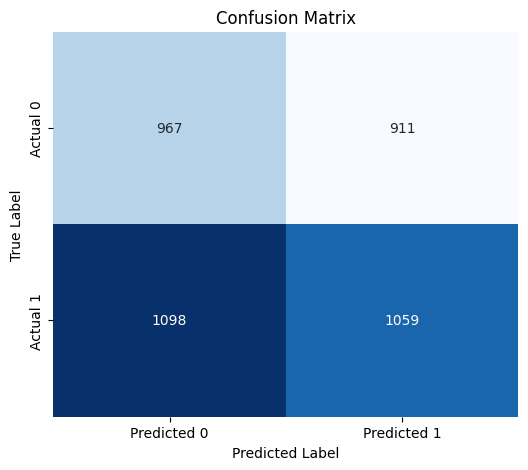

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = bst.predict(X_test_s)
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"Test Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Step 9: Helper prediction function using latest available data in data_dict
def predict_ticker_next_day(ticker, model, scaler, data_dict, feature_cols):
    # check availability
    if ticker not in data_dict:
        raise ValueError(f"{ticker} not in data_dict. Available tickers: {list(data_dict.keys())[:10]}")

    df = data_dict[ticker].copy()
    # featurize safely
    fdf = featurize_safe(df)
    if fdf.shape[0] == 0:
        raise ValueError("Not enough featurized rows for this ticker.")
    last = fdf.iloc[-1]  # last row corresponds to features that predict next-day label
    X = last[feature_cols].values.reshape(1, -1)
    Xs = scaler.transform(X)
    prob = model.predict(Xs)[0]
    pred = int(prob >= 0.5)
    # last.name may be Timestamp from original index
    date_label = last.name if last.name is not None else last.get('Date', None)
    return {'ticker': ticker, 'date_index_or_timestamp': str(date_label), 'prob_up': float(prob), 'pred_up': int(pred)}

# Example usage: replace 'TSLA' with any ticker present in your data_dict
example_ticker = list(data_dict.keys())[0]
print("Example predict for", example_ticker, "->", predict_ticker_next_day(example_ticker, bst, scaler, data_dict, feature_cols))

Example predict for AAPL -> {'ticker': 'AAPL', 'date_index_or_timestamp': '2026-03-23 00:00:00', 'prob_up': 0.712149639025379, 'pred_up': 1}


In [ ]:
# Step 10: Batch Prediction for Multiple Tickers

import yfinance as yf
import pandas as pd
import time
from tqdm import tqdm

def ensure_tickers_in_data_dict(ticker_list, start="2018-01-01", min_rows=60, pause=0.2):
    """Download missing tickers into data_dict if needed."""
    added = []
    for ticker in ticker_list:
        if ticker in data_dict:
            continue
        try:
            df = yf.download(ticker, start=start, progress=False)
            if df is None or df.shape[0] <= min_rows:
                tk = yf.Ticker(ticker)
                hist = tk.history(start=start)
                if hist is None or hist.shape[0] <= min_rows:
                    print(f"Warning: insufficient data for {ticker}")
                    continue
                df = hist
            cols = [c for c in ['Open','High','Low','Close','Adj Close','Volume'] if c in df.columns]
            data_dict[ticker] = df[cols].dropna()
            added.append(ticker)
        except Exception as e:
            print(f"Download error for {ticker}: {e}")
        time.sleep(pause)
    return added

def batch_predict(tickers, model, scaler, data_dict, feature_cols,
                  buy_threshold=0.6, sell_threshold=0.4):
    """
    Predict next-day direction for multiple tickers.
    Returns sorted DataFrame with signal.
    """
    ensure_tickers_in_data_dict(tickers)

    results = []

    for ticker in tqdm(tickers, desc="Predicting"):
        try:
            result = predict_ticker_next_day(
                ticker, model, scaler, data_dict, feature_cols
            )

            prob = result["prob_up"]

            if prob >= buy_threshold:
                signal = "Buy"
            elif prob <= sell_threshold:
                signal = "Sell"
            else:
                signal = "Hold"

            results.append({
                "ticker": ticker,
                "prob_up": prob,
                "pred_up": result["pred_up"],
                "signal": signal,
                "date_index_or_timestamp": result["date_index_or_timestamp"]
            })

        except Exception as e:
            results.append({
                "ticker": ticker,
                "prob_up": None,
                "pred_up": None,
                "signal": "Error",
                "date_index_or_timestamp": str(e)
            })

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values("prob_up", ascending=False, na_position="last")
    df_results = df_results.reset_index(drop=True)

    return df_results

In [ ]:
# Step 11: Execute Batch Prediction and Display Results

tickers_to_check = ["MMM", "TSLA", "AAPL", "MSFT", "NVDA", "AMZN"]

results_df = batch_predict(
    tickers_to_check,
    bst,
    scaler,
    data_dict,
    feature_cols
)

print(results_df)

/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
Predicting: 100%|██████████| 6/6 [00:00<00:00, 37.36it/s]

  ticker   prob_up  pred_up signal date_index_or_timestamp
0   AAPL  0.712150        1    Buy     2026-03-23 00:00:00
1   NVDA  0.647093        1    Buy     2026-03-23 00:00:00
2    MMM  0.637104        1    Buy     2026-03-24 00:00:00
3   TSLA  0.426435        0   Hold     2026-03-23 00:00:00
4   AMZN  0.398100        0   Sell     2026-03-23 00:00:00
5   MSFT  0.365181        0   Sell     2026-03-23 00:00:00




---



---



In [ ]:
# Step 12: Run Batch Prediction Across All S&P 500 Tickers
#
# This cell:
# - Loads the S&P 500 constituents list
# - Splits tickers into manageable chunks to avoid rate limits
# - Runs batch_predict() per chunk, with retries and pause
# - Saves intermediate and final results to CSV files
# - Prints summary statistics and top signals
#
# NOTE: This can take time depending on network and yfinance responses.
# Adjust chunk_size and pause_between_chunks as needed.

import pandas as pd
import time
from tqdm import tqdm
import math
import os

# Parameters you can tweak
START_DATE_FOR_DOWNLOAD = "2018-01-01"   # used by ensure_tickers_in_data_dict if it needs to download
CHUNK_SIZE = 50                          # how many tickers to process per chunk (reduce if you see issues)
PAUSE_BETWEEN_CHUNKS = 5.0               # seconds to sleep between chunks
RETRY_ON_ERROR = 2                       # number of times to retry a failed chunk
OUTPUT_DIR = "./batch_results"
TIMESTAMP = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
FINAL_CSV = os.path.join(OUTPUT_DIR, f"snp500_batch_predictions_{TIMESTAMP}.csv")
INTERMEDIATE_TEMPLATE = os.path.join(OUTPUT_DIR, f"partial_results_chunk_{{chunk_idx}}_{TIMESTAMP}.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1) Load S&P 500 tickers (same source you used earlier)
sp500_url = "https://datahub.io/core/s-and-p-500-companies/r/constituents.csv"
sp500_df = pd.read_csv(sp500_url)
tickers_all = sp500_df['Symbol'].str.replace('.', '-', regex=False).tolist()

print(f"Loaded {len(tickers_all)} tickers (S&P 500 source).")

# 2) Optional: if you purposely were running SAMPLE_ONLY, override it here to run full set
# (Do NOT set SAMPLE_ONLY global unless you want to change notebook behaviour. We just use tickers_all)
tickers_to_run = tickers_all.copy()

# 3) Helper to run chunk with simple retry
def run_chunk(chunk_idx, tickers_chunk):
    for attempt in range(1, RETRY_ON_ERROR + 1):
        try:
            df_chunk = batch_predict(
                tickers_chunk,
                bst,
                scaler,
                data_dict,
                feature_cols,
            )
            # Save intermediate results
            intermediate_path = INTERMEDIATE_TEMPLATE.format(chunk_idx=chunk_idx)
            df_chunk.to_csv(intermediate_path, index=False)
            return df_chunk
        except Exception as e:
            print(f"[Chunk {chunk_idx}] Attempt {attempt} failed with error: {e}")
            if attempt < RETRY_ON_ERROR:
                wait = 3 * attempt
                print(f"[Chunk {chunk_idx}] Retrying after {wait}s...")
                time.sleep(wait)
            else:
                # Create a DataFrame capturing the failures
                print(f"[Chunk {chunk_idx}] Failed after {RETRY_ON_ERROR} attempts. Skipping chunk.")
                failed_df = pd.DataFrame({
                    "ticker": tickers_chunk,
                    "prob_up": [None] * len(tickers_chunk),
                    "pred_up": [None] * len(tickers_chunk),
                    "signal": ["Error"] * len(tickers_chunk),
                    "date_index_or_timestamp": [f"error: {str(e)}"] * len(tickers_chunk)
                })
                # still save
                intermediate_path = INTERMEDIATE_TEMPLATE.format(chunk_idx=chunk_idx)
                failed_df.to_csv(intermediate_path, index=False)
                return failed_df

# 4) Run over all tickers in chunks
all_results = []
n = len(tickers_to_run)
num_chunks = math.ceil(n / CHUNK_SIZE)

print(f"Running predictions in {num_chunks} chunks (chunk_size={CHUNK_SIZE}).")

for i in range(num_chunks):
    start_idx = i * CHUNK_SIZE
    end_idx = min((i + 1) * CHUNK_SIZE, n)
    tickers_chunk = tickers_to_run[start_idx:end_idx]
    print(f"\nProcessing chunk {i+1}/{num_chunks} (tickers {start_idx}..{end_idx-1}) with {len(tickers_chunk)} tickers.")
    chunk_df = run_chunk(i+1, tickers_chunk)
    all_results.append(chunk_df)
    print(f"Chunk {i+1} saved. Sleeping for {PAUSE_BETWEEN_CHUNKS}s before next chunk.")
    time.sleep(PAUSE_BETWEEN_CHUNKS)

# 5) Concatenate and save final CSV
final_df = pd.concat(all_results, ignore_index=True)
final_df.to_csv(FINAL_CSV, index=False)
print(f"\nAll chunks completed. Final results saved to: {FINAL_CSV}")

# 6) Quick summary: counts and top signals
print("\nSummary:")
print(final_df['signal'].value_counts(dropna=False))

# Show top 10 buys and top 10 sells (where prob_up not null)
top_buys = final_df[final_df['prob_up'].notnull()].sort_values('prob_up', ascending=False).head(10)
top_sells = final_df[final_df['prob_up'].notnull()].sort_values('prob_up', ascending=True).head(10)

print("\nTop 10 Buy candidates:")
print(top_buys[['ticker','prob_up','signal','date_index_or_timestamp']])

print("\nTop 10 Sell candidates:")
print(top_sells[['ticker','prob_up','signal','date_index_or_timestamp']])



Loaded 503 tickers (S&P 500 source).
Running predictions in 11 chunks (chunk_size=50).

Processing chunk 1/11 (tickers 0..49) with 50 tickers.


/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download

Chunk 1 saved. Sleeping for 5.0s before next chunk.

Processing chunk 2/11 (tickers 50..99) with 50 tickers.


/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download

Chunk 2 saved. Sleeping for 5.0s before next chunk.

Processing chunk 3/11 (tickers 100..149) with 50 tickers.


...

Chunk 9 saved. Sleeping for 5.0s before next chunk.

Processing chunk 10/11 (tickers 450..499) with 50 tickers.


/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download

Chunk 10 saved. Sleeping for 5.0s before next chunk.

Processing chunk 11/11 (tickers 500..502) with 3 tickers.


/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
/tmp/ipykernel_11649/1680342721.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)
Predicting: 100%|██████████| 3/3 [00:00<00:00, 37.05it/s]


Chunk 11 saved. Sleeping for 5.0s before next chunk.

All chunks completed. Final results saved to: ./batch_results/snp500_batch_predictions_20260324_193953.csv

Summary:
signal
Hold    236
Buy     197
Sell     70
Name: count, dtype: int64

Top 10 Buy candidates:
    ticker   prob_up signal date_index_or_timestamp
100   COIN  0.898422    Buy     2026-03-24 00:00:00
0    GOOGL  0.880739    Buy     2026-03-24 00:00:00
1     GOOG  0.876743    Buy     2026-03-24 00:00:00
150   FICO  0.854367    Buy     2026-03-24 00:00:00
200    GEN  0.852470    Buy     2026-03-24 00:00:00
350    PSA  0.836803    Buy     2026-03-24 00:00:00
201    HAL  0.833108    Buy     2026-03-24 00:00:00
250   INTU  0.831062    Buy     2026-03-24 00:00:00
50      BR  0.810863    Buy     2026-03-24 00:00:00
351    RJF  0.810799    Buy     2026-03-24 00:00:00

Top 10 Sell candidates:
    ticker   prob_up signal date_index_or_timestamp
349    MOS  0.164101   Sell     2026-03-24 00:00:00
149     CB  0.180051   Sell     202

# Code Descriptions

This project builds a machine learning model that predicts the probability that a stock’s closing price will go up the next trading day across all S&P 500 companies. (By using the numbers only)

It uses approximately eight years of daily historical data, from 2018 to 2026.
Data from 2018 to 2022 is used for model training, while data from 2023 onward is reserved for out-of-sample testing.

The model is a 1-day ahead prediction model. It uses up to 20 days of recent technical indicators—such as returns, moving averages, RSI, momentum, and volatility—to estimate whether the next day’s closing price will be higher than today’s.

The output is a probability of upward movement. Based on predefined thresholds, each stock is assigned a Buy, Hold, or Sell signal. The results are saved into a CSV file, and the model identifies the top Buy and Sell candidates across the index.

This is a short-term, daily-frequency model that relies purely on technical indicators. It does not incorporate macroeconomic variables, interest rates, news sentiment, or fundamental data.

# Result Descriptions

- Ticker: the stock's ticker symbol. This identifies the S&P 500 company the prediction refers to.

- prob_up: the model's estimated probability that the stock's closing price will be higher on the next trading day

- pred_up: the binary prediction derived from prob)up (1 --> predicts price will go up, 0 --> predicts price will go down)

- signal: a trading interpretation of the probability

- dat_index_or_timestamp: the last available trading date used to generate the prediction

# Try to collect the news from Google News (f"https://news.google.com/rss/search?q={1}") by Julia - Using VADER for sentiment analysis

STREAMLIT by Yerke

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.8 MB/s eta 0:00:00


KeyboardInterrupt: 

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.title("Stock Prediction Dashboard")

# Upload dataset
uploaded_file = st.file_uploader("Upload your stock dataset (CSV)", type=["csv"])

if uploaded_file is not None:

    df = pd.read_csv(uploaded_file)

    st.write("Dataset preview:")
    st.dataframe(df.head())

    # Select column for visualization
    numeric_columns = df.select_dtypes(include=['float64','int64']).columns

    if len(numeric_columns) > 0:
        column = st.selectbox("Select column to visualize", numeric_columns)

        st.subheader("Line Chart")
        st.line_chart(df[column])

        st.subheader("Bar Chart")
        st.bar_chart(df[column])

        st.subheader("Summary Statistics")
        st.write(df[column].describe())

    else:
        st.warning("No numeric columns found in dataset")

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3AUv8kv4WrawnZiSJWe2EbBRj6J_3BNd4NYxQ7MS2amYQqGGA")

In [ ]:
from pyngrok import ngrok
import subprocess

# IMPORTANT: Replace <YOUR_AUTHTOKEN> with your actual ngrok authtoken.
# You can get one for free at https://dashboard.ngrok.com/get-started/your-authtoken
# ngrok.set_auth_token("<YOUR_AUTHTOKEN>")

# Start streamlit
get_ipython().system_raw('streamlit run app.py --server.port 8501 &')

# Create public URL
public_url = ngrok.connect(8501)
print(public_url)

Downloading the csv file:

In [ ]:
from google.colab import files
import os

output_dir = "./batch_results"

if os.path.exists(output_dir):
    csv_files = [f for f in os.listdir(output_dir) if f.startswith('snp500_batch_predictions_') and f.endswith('.csv')]
    if csv_files:
        # Sort files by modification time and get the latest one
        latest_csv = max(csv_files, key=lambda f: os.path.getmtime(os.path.join(output_dir, f)))
        file_to_download = os.path.join(output_dir, latest_csv)
        print(f"Downloading: {file_to_download}")
        files.download(file_to_download)
    else:
        print(f"No 'snp500_batch_predictions_*.csv' found in {output_dir}. Please ensure Step 12 has been executed.")
else:
    print(f"Output directory {output_dir} not found. Please ensure Step 12 has been executed.")


TESTING small dataset to see if visuals work in new platform by Yerke:

In [ ]:
import pandas as pd
from google.colab import files

data = {
    "Date": ["2024-01-01","2024-01-02","2024-01-03","2024-01-04"],
    "Close": [150,153,155,152],
    "Volume": [1200000,1100000,1300000,1000000]
}

df = pd.DataFrame(data)

df.to_csv("test_stock.csv", index=False)

files.download("test_stock.csv")

In [ ]:
import os
os.listdir()

In [ ]:
!pip install yfinance pandas requests

In [ ]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

sp500_df = tables[0]

tickers = sp500_df["Symbol"].tolist()

print("Total tickers:", len(tickers))
print(tickers[:10])

In [ ]:
import yfinance as yf

data = yf.download(
    tickers,
    start="2024-01-01",
    end="2025-01-01",
    group_by="ticker"
)

In [ ]:
df_list = []

for ticker in tickers:

    if ticker in data.columns.levels[0]:

        temp = data[ticker].copy()
        temp["Ticker"] = ticker
        temp.reset_index(inplace=True)

        df_list.append(temp)

sp500_data = pd.concat(df_list)

sp500_data.head()

In [ ]:
sp500_data.to_csv("sp500_stock_data.csv", index=False)

In [ ]:
from google.colab import files

files.download("sp500_stock_data.csv")

PRICE TRENDS

In [ ]:
import matplotlib.pyplot as plt

# choose 2–3 stocks from your dataset
stocks = ['AAPL', 'MSFT', 'TSLA']

plt.figure(figsize=(10,5))

for stock in stocks:
    data = yf.download(stock, start="2023-01-01", end="2024-01-01")
    plt.plot(data['Close'], label=stock)

plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# after training your LightGBM model
importances = bst.feature_importance()
features = feature_cols

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()

plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(y_test[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.title("Actual vs Predicted Stock Movement")
plt.xlabel("Observations")
plt.ylabel("Movement (0/1)")
plt.legend()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# --- Figures for Symposium ---

plt.style.use('seaborn-v0_8-darkgrid') # Set a nice style for plots

# 1. Probability Distribution of Predictions
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_prob, bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Predicted Probabilities (Next-Day Up Movement)', fontsize=14)
plt.xlabel('Probability of Up Movement', fontsize=12)
plt.ylabel('Number of Predictions', fontsize=12)
plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Bar Charts for Top Buy and Top Sell Signals
plt.figure(figsize=(12, 6))

# Top 10 Buy Candidates
plt.subplot(1, 2, 1)
sns.barplot(x='prob_up', y='ticker', data=top_buys.head(10), palette='viridis')
plt.title('Top 10 Buy Signals (Highest Probability Up)', fontsize=14)
plt.xlabel('Probability of Up Movement', fontsize=12)
plt.ylabel('Ticker', fontsize=12)
plt.xlim(0.4, 1.0) # Focus on buy probability range
plt.tight_layout()

# Top 10 Sell Candidates
plt.subplot(1, 2, 2)
sns.barplot(x='prob_up', y='ticker', data=top_sells.head(10), palette='magma')
plt.title('Top 10 Sell Signals (Lowest Probability Up)', fontsize=14)
plt.xlabel('Probability of Up Movement', fontsize=12)
plt.ylabel('Ticker', fontsize=12)
plt.xlim(0.0, 0.6) # Focus on sell probability range
plt.tight_layout()

plt.show()

# 3. Feature Importance (re-display from POy0RuHNzdfE)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='cubehelix')
plt.title('Feature Importance (LightGBM)', fontsize=14)
plt.xlabel('Importance (F-score)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Confusion Matrix (re-display from FBtmkk3Otg-4)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Down (0)', 'Predicted Up (1)'],
            yticklabels=['Actual Down (0)', 'Actual Up (1)'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# 5. Actual vs Predicted Stock Movement (re-display from gvan83EQ0EEt)
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label="Actual Movement (Test Set)", color='blue', alpha=0.7)
plt.plot(y_pred[:100], label="Predicted Movement (Test Set)", color='red', linestyle='--', alpha=0.7)
plt.title('Actual vs. Predicted Stock Movement (First 100 Test Observations)', fontsize=14)
plt.xlabel('Observation Index', fontsize=12)
plt.ylabel('Movement (0: Down, 1: Up)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The LightGBM model achieved an accuracy of 0.5090 and an AUC (Area Under the Receiver Operating Characteristic curve) of 0.5034 on the test set for predicting next-day S\&P 500 stock movements. The AUC value indicates that the model's ability to distinguish between positive and negative instances is weak, implying limited predictive power for short-term directional changes with the current approach.
*   **Feature Importance**: `vol_change`, `vol_20`, and various `returns` features were identified as the most influential in the model's predictions, highlighting the significance of volatility and recent price action.
*   **Signal Generation**: The model uses prediction probabilities to generate actionable "Buy" (probability of up movement $\ge$ 0.6), "Hold" (0.4 $<$ probability $<$ 0.6), and "Sell" (probability $\le$ 0.4) signals.
*   **Predicted Probability Distribution**: The distribution of predicted probabilities for next-day upward movement is clustered around 0.5, further supporting the observation of limited strong predictive signals.
*   The pipeline demonstrates scalability, capable of processing and generating predictions for all S\&P 500 tickers in chunks.

### Insights or Next Steps

*   To enhance predictive accuracy, future work should explore incorporating fundamental data, macroeconomic factors, and news sentiment, as the current model's purely technical approach appears insufficient for robust short-term stock movement prediction.
*   Investigate more advanced machine learning or deep learning architectures, potentially combined with a more diverse feature set, to capture complex non-linear relationships that might improve the model's ability to identify stronger predictive signals.


## **Project: Predicting Stock Market Direction (S&P 500)**

## **1. Idea (Hypothesis)**
We thought a machine learning model could **predict whether stock prices go up or down the next day** using past price data.

## **2. What we did (Method)**
- Collected stock data (prices + volume) from 2018–now  
- Created helpful indicators like:
  - **Recent price changes**  
  - **Moving averages**  
  - **Volatility** (how much prices move)  
  - **Momentum and trading volume**  

- Trained a model (**LightGBM**) to:
  - Predict **1 = price goes up**
  - Predict **0 = price goes down**

- Tested the model on newer data to see how well it works  

## **3. What we found (Results)**
- The model is **about 50% accurate**, which is basically **like guessing**
- It struggles to clearly tell when stocks will go up vs down  

- The most useful signals were:
  - **Volatility**
  - **Recent price changes**

- The model gives simple signals:
  - **Buy** (thinks price will go up)
  - **Hold** (unsure)
  - **Sell** (thinks price will go down)

- It can handle **all S&P 500 stocks efficiently**  

## **4. What this means (Conclusion)**
- Using only past price data is **not enough** to predict short-term stock movements well  
- The model misses important factors like:
  - **News**
  - **Economic conditions**
  - **Company performance**

## **5. What’s next (Improvements)**
- Add more data (news, financials, economy)  
- Try more advanced models  